In [1]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

In [26]:
def crop_breast(img):
        _, thresh = cv2.threshold(img, 10, 255, cv2.THRESH_BINARY)
        contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        if not contours:
            return img
        largest = max(contours, key=cv2.contourArea)
        x, y, w, h = cv2.boundingRect(largest)
        return img[y:y+h, x:x+w], (x, y, w, h)  # return crop + original coords


#TODO: remove pectoral when working on dicom. Mammoclip - not sure
def remove_pectoral(img_crop):
        # Basic: remove top-right triangle (common for MLO)
        h, w = img_crop.shape
        mask = np.ones_like(img_crop, dtype=np.uint8) * 255
        cv2.fillConvexPoly(mask, np.array([[w, 0], [w, int(h*0.4)], [int(w*0.6), 0]]), 0)
        return cv2.bitwise_and(img_crop, img_crop, mask=mask)


def register(left, right_flipped):
    # 6. ECC Registration (affine)
    warp_matrix = np.eye(2, 3, dtype=np.float32)  # affine
    criteria = (cv2.TERM_CRITERIA_EPS | cv2.TERM_CRITERIA_COUNT, 500, 1e-6)

    # Optional: downsample for faster registration
    # scale = 0.5
    # left_small = cv2.resize(left, None, fx=scale, fy=scale)
    # right_small = cv2.resize(right_flipped, None, fx=scale, fy=scale)

    cc, warp_matrix = cv2.findTransformECC(left, right_flipped, warp_matrix, cv2.MOTION_AFFINE, criteria)

    # Apply warp at original crop resolution
    right_registered = cv2.warpAffine(right_flipped, warp_matrix, (left.shape[1], left.shape[0]), 
                                        flags=cv2.INTER_LINEAR + cv2.WARP_INVERSE_MAP)

    # 7. Difference map
    diff = cv2.absdiff(left, right_registered)
    diff = cv2.normalize(diff, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

    return diff


In [27]:
file_left_cc = '../data/vindr/images_png/0025a5dc99fd5c742026f0b2b030d3e9/451562831387e2822923204cf8f0873e.png'
file_right_cc = '../data/vindr/images_png/0025a5dc99fd5c742026f0b2b030d3e9/fcf12c2803ba8dc564bf1287c0c97d9a.png'
file_left_mlo = '../data/vindr/images_png/0025a5dc99fd5c742026f0b2b030d3e9/2ddfad7286c2b016931ceccd1e2c7bbc.png'
file_right_mlo = '../data/vindr/images_png/0025a5dc99fd5c742026f0b2b030d3e9/47c8858666bcce92bcbd57974b5ce522.png'



img_left_cc = cv2.imread(file_left_cc, cv2.IMREAD_UNCHANGED)
img_right_cc = cv2.imread(file_right_cc, cv2.IMREAD_UNCHANGED)
img_left_mlo = cv2.imread(file_left_mlo, cv2.IMREAD_UNCHANGED)
img_right_mlo = cv2.imread(file_right_mlo, cv2.IMREAD_UNCHANGED)

images = [img_left_cc, img_right_cc, img_left_mlo, img_right_mlo]
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))

cropped_l_cc, cropped_r_cc, cropped_l_mlo, cropped_r_mlo = [clahe.apply(crop_breast(img)[0]) for img in images]
right_cc_fliped = cv2.flip(cropped_r_cc, 1)
right_mlo_fliped = cv2.flip(cropped_r_mlo, 1)


dif_cc = register(cropped_l_cc, right_cc_fliped)
dif_mlo = register(cropped_l_mlo, right_mlo_fliped)



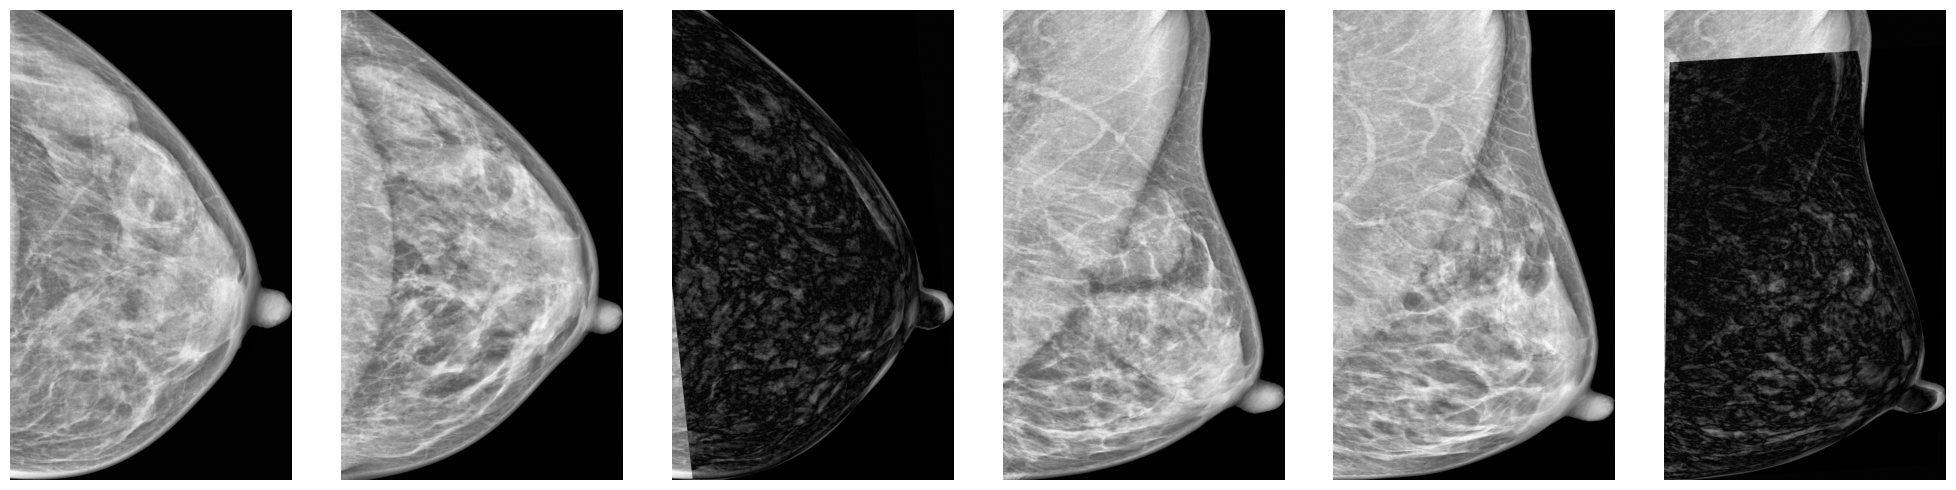

In [28]:

fig, axs = plt.subplots(1, 6, figsize=(20, 5))
axs[0].imshow(cropped_l_cc, cmap='gray')
axs[1].imshow(right_cc_fliped, cmap='gray')
axs[2].imshow(dif_cc, cmap='gray')
axs[3].imshow(cropped_l_mlo, cmap='gray')
axs[4].imshow(right_mlo_fliped, cmap='gray')
axs[5].imshow(dif_mlo, cmap='gray')

for ax in axs:
    ax.axis('off')

plt.tight_layout()
plt.show()



In [40]:
file_left_cc = '../data/vindr/images_png/5babce4b963ba18124477ce11d284ac6/3fde15ab69283b96c1c24538427e7212.png'
file_right_cc = '../data/vindr/images_png/5babce4b963ba18124477ce11d284ac6/1f4fb6c038caaae9d00d4cd5387de5e9.png'
file_left_mlo = '../data/vindr/images_png/5babce4b963ba18124477ce11d284ac6/b0251c254808b8d6de51d69952fb35d0.png'
file_right_mlo = '../data/vindr/images_png/5babce4b963ba18124477ce11d284ac6/1f2a0fcf534d8a93502a4969db4ee555.png'

img_left_cc = cv2.imread(file_left_cc, cv2.IMREAD_UNCHANGED)
img_right_cc = cv2.imread(file_right_cc, cv2.IMREAD_UNCHANGED)
img_left_mlo = cv2.imread(file_left_mlo, cv2.IMREAD_UNCHANGED)
img_right_mlo = cv2.imread(file_right_mlo, cv2.IMREAD_UNCHANGED)

images = [img_left_cc, img_right_cc, img_left_mlo, img_right_mlo]
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))

cropped_l_cc, cropped_r_cc, cropped_l_mlo, cropped_r_mlo = [clahe.apply(crop_breast(img)[0]) for img in images]
right_cc_fliped = cv2.flip(cropped_r_cc, 1)
right_mlo_fliped = cv2.flip(cropped_r_mlo, 1)


dif_cc = register(cropped_l_cc, right_cc_fliped)
dif_mlo = register(cropped_l_mlo, right_mlo_fliped)



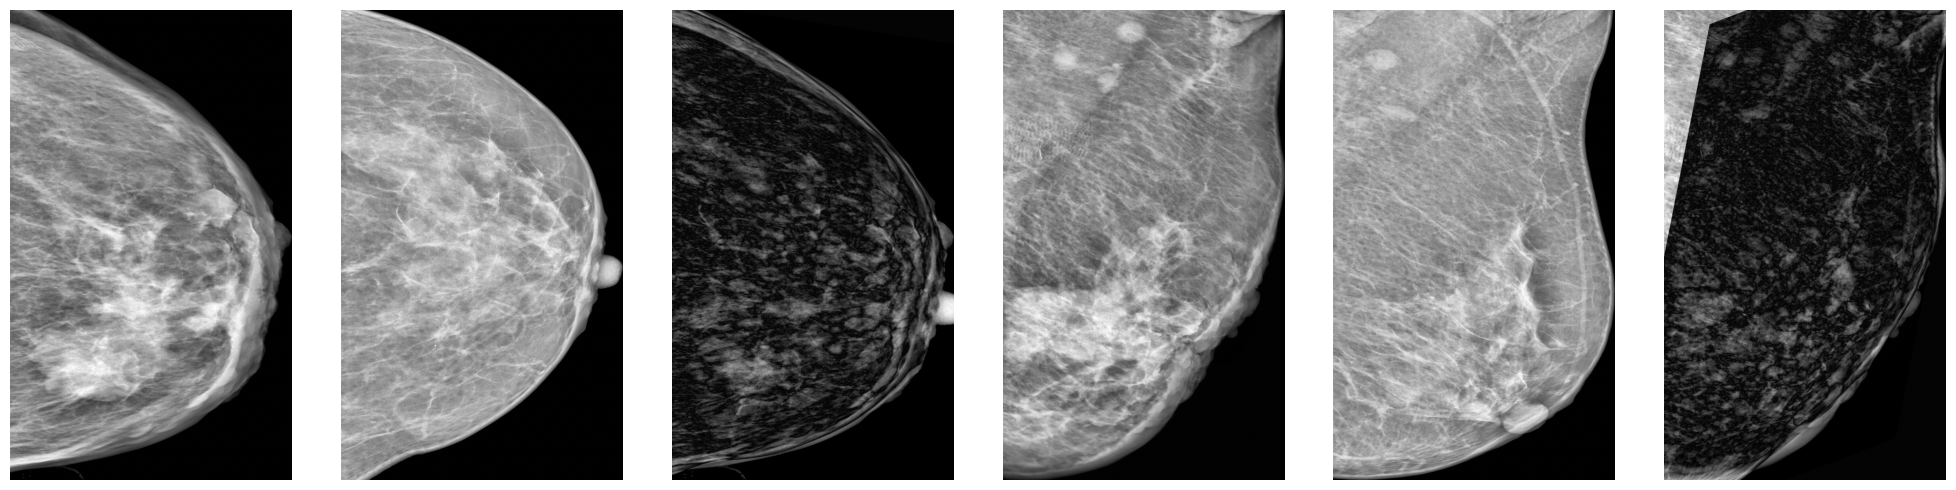

In [41]:
fig, axs = plt.subplots(1, 6, figsize=(20, 5))
axs[0].imshow(cropped_l_cc, cmap='gray')
axs[1].imshow(right_cc_fliped, cmap='gray')
axs[2].imshow(dif_cc, cmap='gray')
axs[3].imshow(cropped_l_mlo, cmap='gray')
axs[4].imshow(right_mlo_fliped, cmap='gray')
axs[5].imshow(dif_mlo, cmap='gray')

for ax in axs:
    ax.axis('off')

plt.tight_layout()
plt.show()



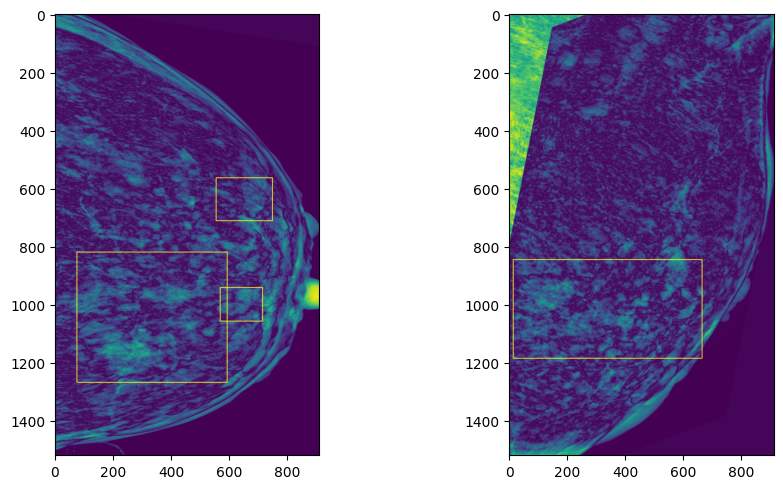

In [45]:
bbox1=[554.815251,	564.2093279,	748.1801849,	712.1071771]
bbox2=[568.4324617,	942.3340973,	714.1365394,	1058.212994]
bbox3=[75.486124,	820.3604998,	592.9426182,	1269.386709]
bbox_mlo=[14.77853275,	846.3542597,	664.3422994,	1186.544736]

img = dif_cc.copy()
img = cv2.rectangle(img, (int(bbox1[0]), int(bbox1[1])), (int(bbox1[2]), int(bbox1[3])), color=(255,255,0), thickness=2)
img = cv2.rectangle(img, (int(bbox2[0]), int(bbox2[1])), (int(bbox2[2]), int(bbox2[3])), color=(255,255,0), thickness=2)
img = cv2.rectangle(img, (int(bbox3[0]), int(bbox3[1])), (int(bbox3[2]), int(bbox3[3])), color=(255,255,0), thickness=2)

img1 = dif_mlo.copy()
img1 = cv2.rectangle(img1, (int(bbox_mlo[0]), int(bbox_mlo[1])), (int(bbox_mlo[2]), int(bbox_mlo[3])), color=(255,255,0), thickness=2)

fig, axs = plt.subplots(1, 2, figsize = (10, 5))
axs[0].imshow(img)
axs[1].imshow(img1)
plt.tight_layout()
plt.show()
